In [88]:
import pandas as pd
from matplotlib.pyplot import ylabel, xlabel

In [ ]:
df1 = pd.read_csv("../data/merged/movieLens.csv")
df1.head()

In [ ]:
df2 = pd.read_csv("../data/tmdb/final_tmdb_data_OLD.csv")
df2.head()

In [91]:
df1.shape,df2.shape

((9790, 14), (9660, 17))

In [92]:
merged = pd.merge(df1,df2,on = 'tmdbId',how = 'inner')

In [93]:
merged.head()

,tconst,imdbId,tmdbId,movieId,primaryTitle,isAdult,year_x,domestic_million_usd,overseas_million_usd,world_million_usd,...,popularity,vote_average,vote_count,genres,origin_countries,spoken_languages,directors,writers,cast,keywords
0,tt0003471,3471,96128.0,135706,Traffic in Souls,0,1913.0,1.0,NaN,1.0,...,0.6955,5.000,22,"Crime, Drama",United States of America,"No Language, English",George Loane Tucker,NaN,"Jane Gail, Ethel Grandin, William H. Turner, M...","kidnapping, prostitution, silent film"
1,tt0005059,5059,415021.0,168578,The Captive,0,1915.0,0.1,NaN,0.1,...,0.4851,6.000,8,"War, Drama, Romance",United States of America,No Language,Cecil B. DeMille,"Cecil B. DeMille, Jeanie Macpherson","Blanche Sweet, House Peters, Gerald Ward, Page...",silent film
2,tt0005393,5393,402388.0,270428,The Girl of the Golden West,0,1915.0,0.1,NaN,0.1,...,0.2104,5.500,6,"Western, Romance",United States of America,"English, No Language",Cecil B. DeMille,Cecil B. DeMille,"Mabel Van Buren, Theodore Roberts, House Peter...","gambling, snowstorm, silent film"
3,tt0006333,6333,30266.0,62383,"20,000 Leagues Under the Sea",0,1916.0,8.0,NaN,8.0,...,0.5860,6.164,61,"Adventure, Drama, Action, Science Fiction",United States of America,No Language,Stuart Paton,NaN,"Allen Holubar, Jane Gail, Howard Crampton, Mat...","revenge, captain nemo"
4,tt0008329,8329,400749.0,167812,Mothers of Men,0,1917.0,NaN,0.0,0.0,...,0.5357,4.000,1,Drama,United States of America,NaN,Willis Robards,Hal Reid,"Dorothy Davenport, Willis Robards, Hal Reid, A...",sabotage


In [94]:
merged.columns

Index(['tconst', 'imdbId', 'tmdbId', 'movieId', 'primaryTitle', 'isAdult',
       'year_x', 'domestic_million_usd', 'overseas_million_usd',
       'world_million_usd', 'runtimeMinutes', 'genres_x', 'genres_y',
       'top_5_tags', 'title', 'budget', 'revenue', 'release_date', 'runtime',
       'original_language', 'popularity', 'vote_average', 'vote_count',
       'genres', 'origin_countries', 'spoken_languages', 'directors',
       'writers', 'cast', 'keywords'],
      dtype='str')

In [95]:
merged = merged.drop(columns=['title','runtimeMinutes','year_x','genres_y','top_5_tags','revenue'])
merged.columns

Index(['tconst', 'imdbId', 'tmdbId', 'movieId', 'primaryTitle', 'isAdult',
       'domestic_million_usd', 'overseas_million_usd', 'world_million_usd',
       'genres_x', 'budget', 'release_date', 'runtime', 'original_language',
       'popularity', 'vote_average', 'vote_count', 'genres',
       'origin_countries', 'spoken_languages', 'directors', 'writers', 'cast',
       'keywords'],
      dtype='str')

In [96]:
import matplotlib.pyplot as plt

In [97]:
world = merged['world_million_usd'].sum()
usa = merged['domestic_million_usd'].sum()
international = merged['overseas_million_usd'].sum()
names = ['world','usa','overseas']
values = [world,usa,international]

[Text(0, 0, '446,013'), Text(0, 0, '236,656'), Text(0, 0, '209,353')]

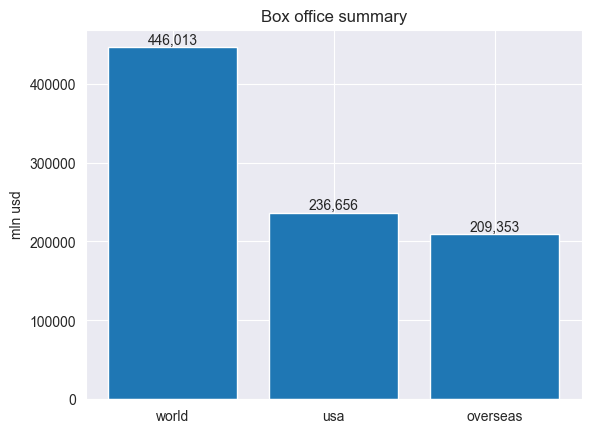

In [98]:
fig, ax = plt.subplots()
bar_container = ax.bar(names,values)
ax.set(ylabel='mln usd', title='Box office summary')
ax.bar_label(bar_container, fmt='{:,.0f}')


In [99]:
world = merged['budget']

In [100]:
budget = world/1_000_000
rev = merged['world_million_usd']
rev

0        1.0
1        0.1
2        0.1
3        8.0
4        0.0
        ... 
9773     0.1
9774     0.3
9775    33.2
9776    10.2
9777     0.3
Name: world_million_usd, Length: 9778, dtype: float64

[Text(0, 0.5, 'revenue in mln usd'), Text(0.5, 0, 'budget in mln usd')]

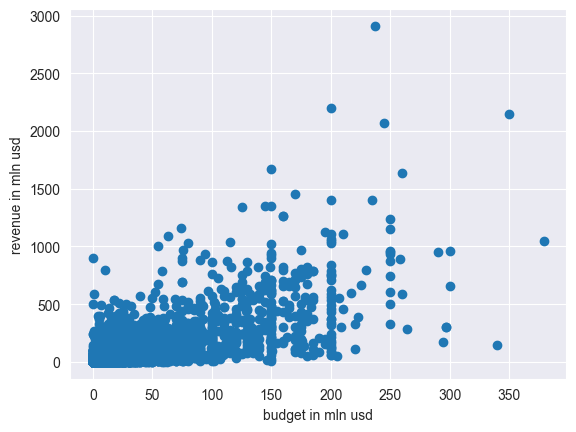

In [101]:
fig,ax = plt.subplots()
ax.scatter(budget,rev)
ax.set(ylabel = 'revenue in mln usd',xlabel = 'budget in mln usd')

In [102]:
usd_vote = merged[['vote_average','world_million_usd']]#
usd_vote['vote_average_rounded'] = usd_vote['vote_average'].round()
vote_vs_revenue = usd_vote.groupby('vote_average_rounded')['world_million_usd'].sum().reset_index()
names = vote_vs_revenue['vote_average_rounded']
values = vote_vs_revenue['world_million_usd']

[Text(0, 0, '12'),
 Text(0, 0, '1'),
 Text(0, 0, '12'),
 Text(0, 0, '311'),
 Text(0, 0, '2,427'),
 Text(0, 0, '17,660'),
 Text(0, 0, '148,452'),
 Text(0, 0, '199,032'),
 Text(0, 0, '77,788'),
 Text(0, 0, '317'),
 Text(0, 0, '1')]

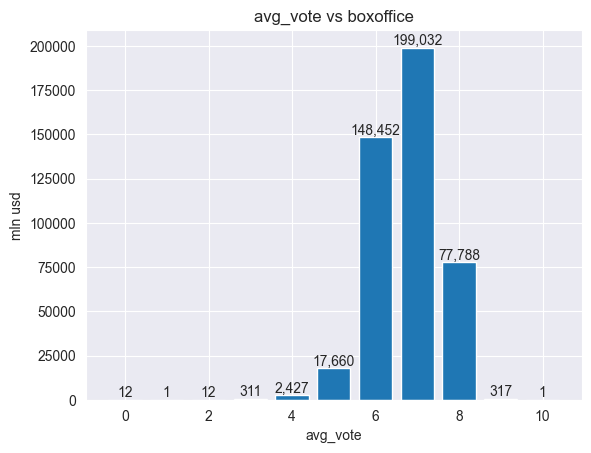

In [103]:
fig, ax = plt.subplots()
bar_container = ax.bar(names,values)
ax.set(ylabel='mln usd', title='avg_vote vs boxoffice',xlabel = 'avg_vote')
ax.bar_label(bar_container, fmt='{:,.0f}')

In [104]:
genres_and_boxoffice = merged[['genres','world_million_usd']]

In [105]:
genres_and_boxoffice

,genres,world_million_usd
0,"Crime, Drama",1.0
1,"War, Drama, Romance",0.1
2,"Western, Romance",0.1
3,"Adventure, Drama, Action, Science Fiction",8.0
4,Drama,0.0
...,...,...
9773,"Crime, Drama, Thriller",0.1
9774,"Western, Drama",0.3
9775,"Horror, Thriller, Mystery",33.2
9776,"Documentary, Music",10.2


In [106]:
genres_and_boxoffice['genres'] = genres_and_boxoffice['genres'].str.split(',')
df_exploded = genres_and_boxoffice.explode('genres')
df_exploded['genres'] = df_exploded['genres'].str.strip()

In [107]:
genre_revenue=df_exploded.groupby('genres').sum().reset_index()
genre_revenue.columns

Index(['genres', 'world_million_usd'], dtype='str')

(np.float64(-1.0999992884777965),
 np.float64(1.099999920917163),
 np.float64(-1.0999995472339772),
 np.float64(1.0999999977132784))

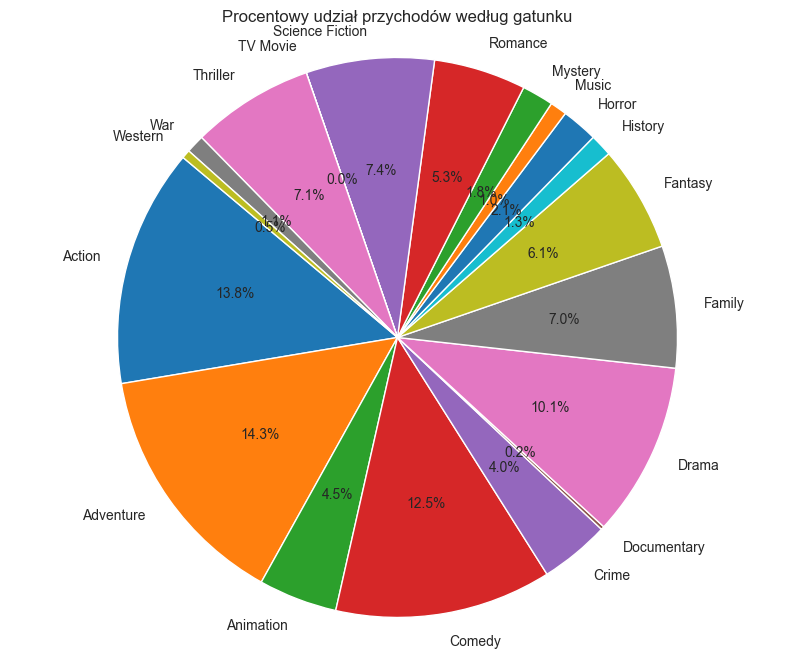

In [108]:
plt.figure(figsize=(10, 8))
plt.pie(genre_revenue['world_million_usd'],
        labels=genre_revenue['genres'],
        autopct='%1.1f%%',
        startangle=140)
plt.title('Procentowy udział przychodów według gatunku')
plt.axis('equal')  # Zapewnia, że wykres jest kołem

In [109]:
year_vs_usd = merged[['release_date','world_million_usd']]
year_vs_usd['release_date'] = pd.to_datetime(year_vs_usd['release_date'])
year_vs_usd['year'] = year_vs_usd['release_date'].dt.year
yearly_revenue = year_vs_usd.groupby('year')['world_million_usd'].sum().reset_index()

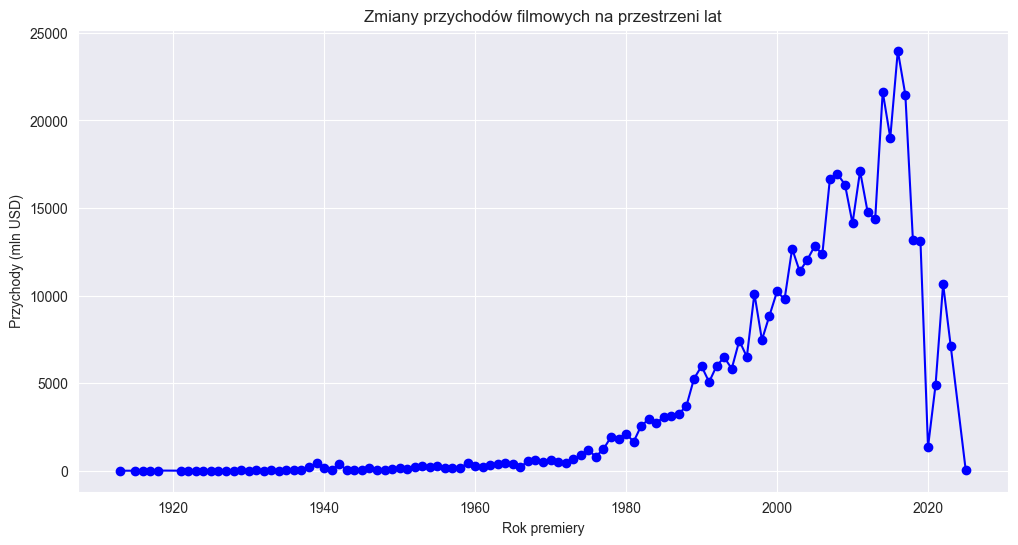

In [110]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_revenue['year'], yearly_revenue['world_million_usd'],
         marker='o', linestyle='-', color='b')

plt.title('Zmiany przychodów filmowych na przestrzeni lat')
plt.xlabel('Rok premiery')
plt.ylabel('Przychody (mln USD)')
plt.grid(True)

In [111]:
merged_numeric = merged.drop(columns = ['imdbId','tmdbId','movieId','isAdult'])
merged_numeric = merged_numeric.select_dtypes(include=['number'])
corr_matrix = merged_numeric.corr()


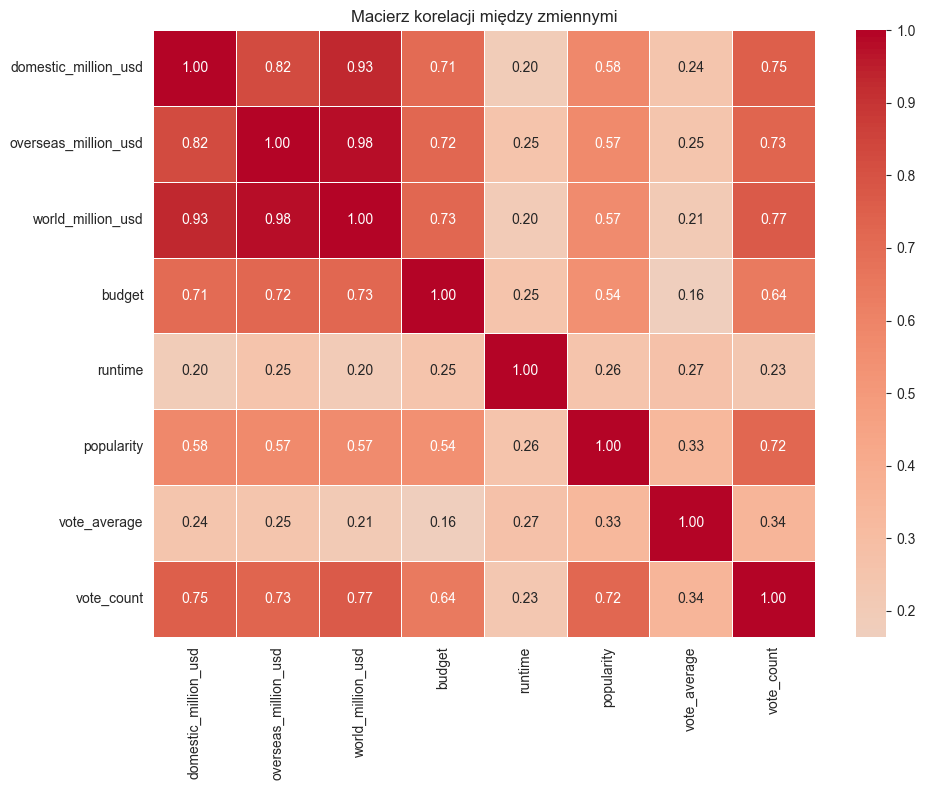

In [112]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=.5)
plt.title('Macierz korelacji między zmiennymi')
plt.tight_layout()
plt.show()


In [113]:
directors_vs_revenue = merged[['directors','world_million_usd']]

In [114]:
directors_vs_revenue['directors'] = directors_vs_revenue['directors'].str.split(',')
df_exploded = directors_vs_revenue.explode('directors')
df_exploded['directors'] = df_exploded['directors'].str.strip()  # Usuń białe znaki

# Zsumuj przychody dla każdego reżysera
director_revenue = df_exploded.groupby('directors')['world_million_usd'].sum().reset_index().sort_values('world_million_usd', ascending=False)
top_10_directors = director_revenue.sort_values('world_million_usd', ascending=False).head(10)
top_10_directors

,directors,world_million_usd
4727,Steven Spielberg,8929.9
2055,James Cameron,8366.2
3375,Michael Bay,6636.0
1222,David Yates,5404.8
2545,Jon Favreau,4884.4
4428,Sam Raimi,4120.4
4171,Ridley Scott,3804.3
3987,Pierre Coffin,3708.1
892,Christopher Nolan,3382.1
1575,Francis Lawrence,3253.7


In [115]:
director_revenue

,directors,world_million_usd
4727,Steven Spielberg,8929.9
2055,James Cameron,8366.2
3375,Michael Bay,6636.0
1222,David Yates,5404.8
2545,Jon Favreau,4884.4
...,...,...
358,Apichatpong Weerasethakul,0.0
357,Anurag Kashyap,0.0
5170,Zackary Adler,0.0
5166,Zach Math,0.0


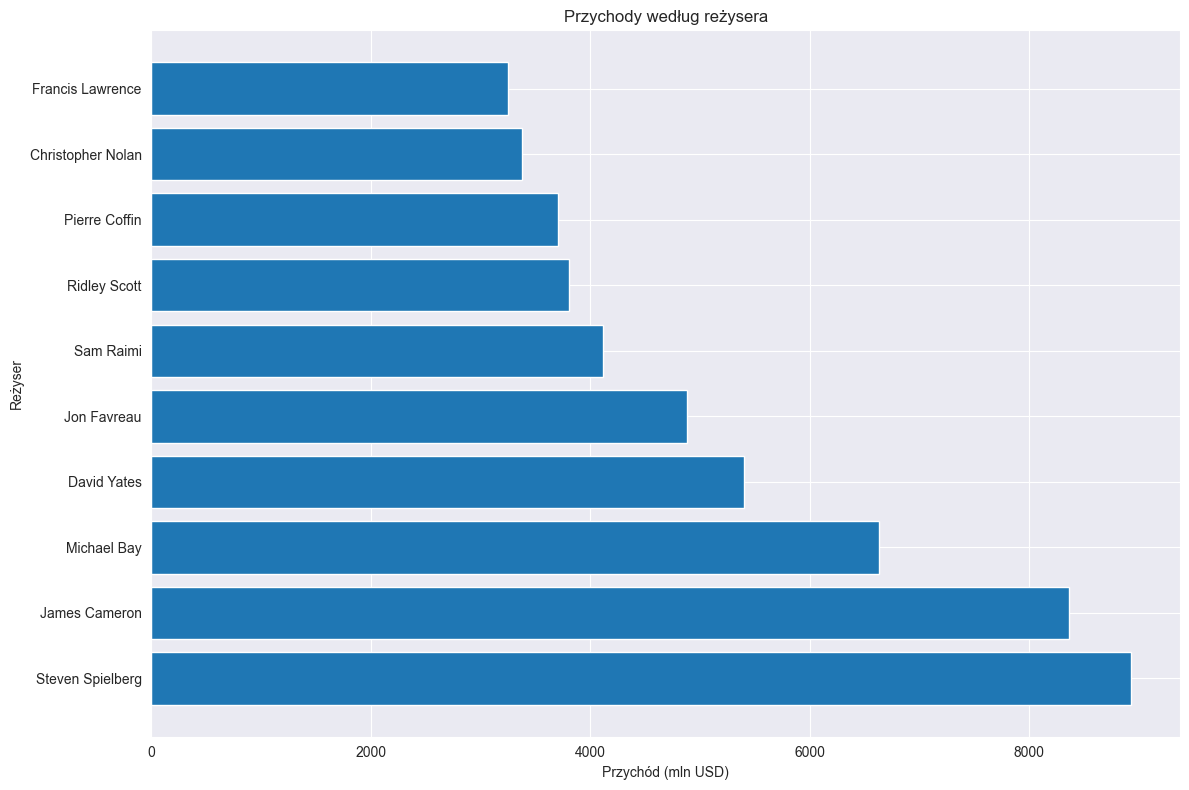

In [116]:
plt.figure(figsize=(12, 8))
plt.barh(top_10_directors['directors'], top_10_directors['world_million_usd'])
plt.title('Przychody według reżysera')
plt.xlabel('Przychód (mln USD)')
plt.ylabel('Reżyser')
plt.tight_layout()
plt.show()

In [117]:
top_100_directors = director_revenue.sort_values('world_million_usd', ascending=False).head(100)

# Oblicz sumę przychodów top 10
sum_top_100 = top_100_directors['world_million_usd'].sum()

# Oblicz sumę przychodów pozostałych reżyserów
sum_rest = director_revenue[~director_revenue['directors'].isin(top_100_directors['directors'])]['world_million_usd'].sum()

# Utwórz DataFrame do porównania
comparison = pd.DataFrame({
    'directors': ['Top 100', 'Reszta'],
    'world_million_usd': [sum_top_100, sum_rest]
})

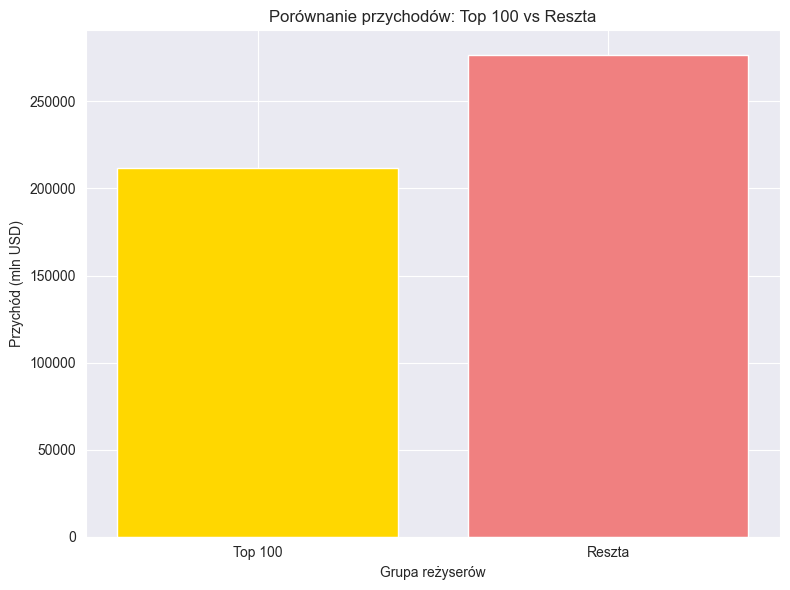

In [118]:
plt.figure(figsize=(8, 6))
plt.bar(comparison['directors'], comparison['world_million_usd'], color=['gold', 'lightcoral'])
plt.title('Porównanie przychodów: Top 100 vs Reszta')
plt.xlabel('Grupa reżyserów')
plt.ylabel('Przychód (mln USD)')
plt.tight_layout()
plt.show()

In [119]:
merged.columns

Index(['tconst', 'imdbId', 'tmdbId', 'movieId', 'primaryTitle', 'isAdult',
       'domestic_million_usd', 'overseas_million_usd', 'world_million_usd',
       'genres_x', 'budget', 'release_date', 'runtime', 'original_language',
       'popularity', 'vote_average', 'vote_count', 'genres',
       'origin_countries', 'spoken_languages', 'directors', 'writers', 'cast',
       'keywords'],
      dtype='str')

In [120]:
actors_and_usd = merged[['cast','world_million_usd']]

actors_and_usd['cast'] = actors_and_usd['cast'].str.split(',')
actors_and_usd = actors_and_usd.explode('cast')
actors_and_usd['cast'] = actors_and_usd['cast'].str.strip()
# Zsumuj przychody dla każdego aktora
actor_revenue = actors_and_usd.groupby('cast')['world_million_usd'].sum().reset_index()

# Sortuj malejąco i wybierz top 10
top_10_actors = actor_revenue.sort_values('world_million_usd', ascending=False).head(10)

# Oblicz sumę przychodów top 10
sum_top_10 = top_10_actors['world_million_usd'].sum()

# Oblicz sumę przychodów pozostałych aktorów
sum_rest = actor_revenue[~actor_revenue['cast'].isin(top_10_actors['cast'])]['world_million_usd'].sum()

# Utwórz DataFrame do porównania
comparison = pd.DataFrame({
    'cast': ['Top 10', 'Reszta'],
    'world_million_usd': [sum_top_10, sum_rest]
})

In [121]:
actors_and_usd

,cast,world_million_usd
0,Jane Gail,1.0
0,Ethel Grandin,1.0
0,William H. Turner,1.0
0,Matt Moore,1.0
0,William Welsh,1.0
...,...,...
9777,Sophia Ali,0.3
9777,Manisha Koirala,0.3
9777,Adil Hussain,0.3
9777,Deepti Gupta,0.3


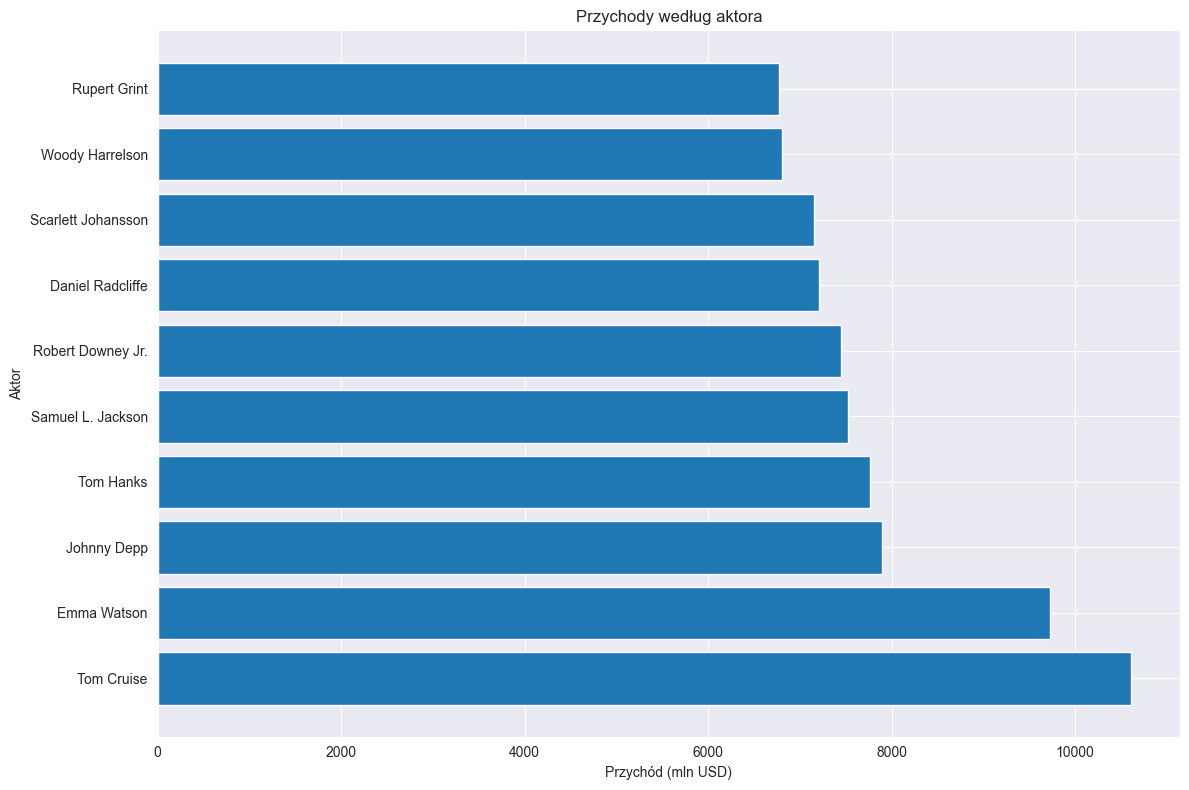

In [122]:
plt.figure(figsize=(12, 8))
plt.barh(top_10_actors['cast'], top_10_actors['world_million_usd'])
plt.title('Przychody według aktora')
plt.xlabel('Przychód (mln USD)')
plt.ylabel('Aktor')
plt.tight_layout()
plt.show()

In [123]:
top_10_actors

,cast,world_million_usd
17834,Tom Cruise,10611.3
5351,Emma Watson,9727.0
9072,Johnny Depp,7891.4
17849,Tom Hanks,7759.2
16079,Samuel L. Jackson,7529.5
15387,Robert Downey Jr.,7449.6
3904,Daniel Radcliffe,7208.9
16268,Scarlett Johansson,7150.9
18823,Woody Harrelson,6805.7
15827,Rupert Grint,6775.5


In [124]:
df = merged[['writers','world_million_usd']]
df['writers'] = df['writers'].str.split(',')
df_exploded = df.explode('writers')
df_exploded['writers'] = df_exploded['writers'].str.strip()

# Zsumuj przychody dla każdego scenarzysty
writer_revenue = df_exploded.groupby('writers')['world_million_usd'].sum().reset_index()

# Sortuj malejąco i wybierz top 10
top_10_writers = writer_revenue.sort_values('world_million_usd', ascending=False).head(10)

# Oblicz sumę przychodów top 10
sum_top_10 = top_10_writers['world_million_usd'].sum()

# Oblicz sumę przychodów pozostałych scenarzystów
sum_rest = writer_revenue[~writer_revenue['writers'].isin(top_10_writers['writers'])]['world_million_usd'].sum()

# Utwórz DataFrame do porównania
comparison = pd.DataFrame({
    'writers': ['Top 10', 'Reszta'],
    'world_million_usd': [sum_top_10, sum_rest]
})

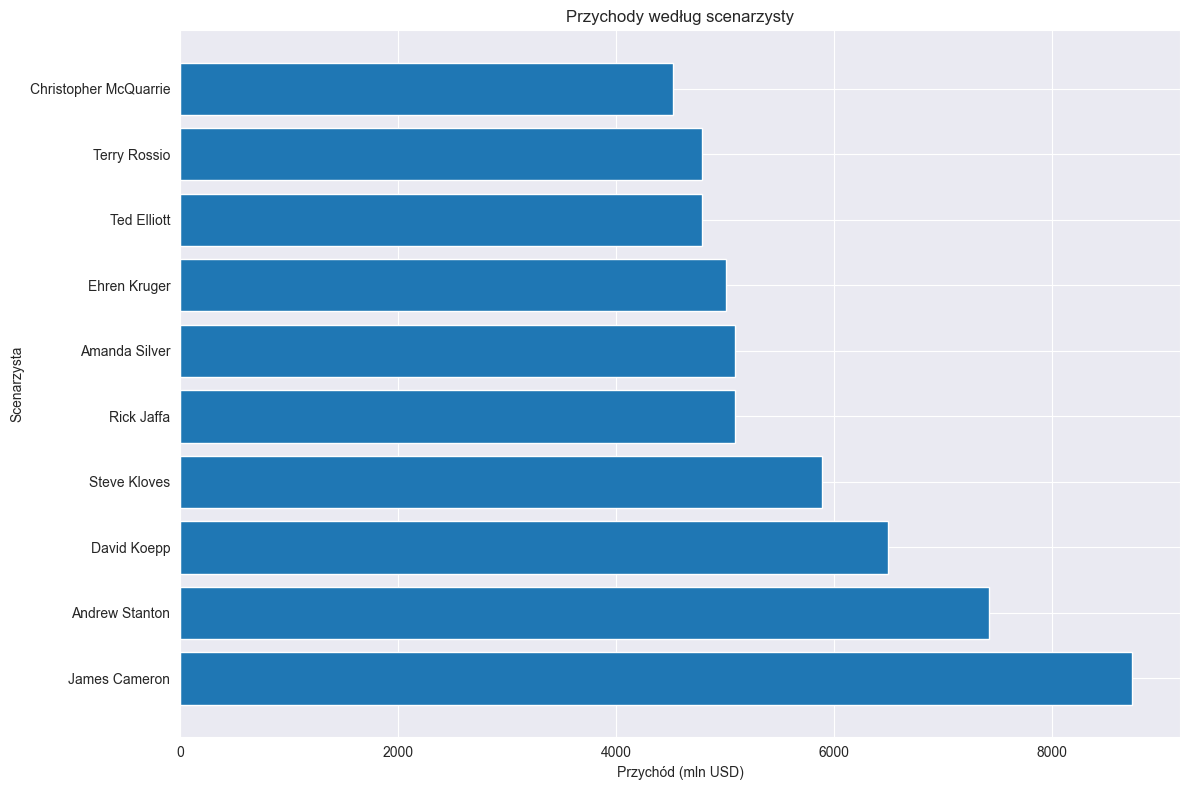

In [125]:
plt.figure(figsize=(12, 8))
plt.barh(top_10_writers['writers'], top_10_writers['world_million_usd'])
plt.title('Przychody według scenarzysty')
plt.xlabel('Przychód (mln USD)')
plt.ylabel('Scenarzysta')
plt.tight_layout()
plt.show()

In [126]:
merged.columns

Index(['tconst', 'imdbId', 'tmdbId', 'movieId', 'primaryTitle', 'isAdult',
       'domestic_million_usd', 'overseas_million_usd', 'world_million_usd',
       'genres_x', 'budget', 'release_date', 'runtime', 'original_language',
       'popularity', 'vote_average', 'vote_count', 'genres',
       'origin_countries', 'spoken_languages', 'directors', 'writers', 'cast',
       'keywords'],
      dtype='str')

In [127]:
keywords_and_rev = merged[['keywords','world_million_usd']]
keywords_and_rev['keywords'] = keywords_and_rev['keywords'].str.split(',')
df_exploded = keywords_and_rev.explode('keywords')
df_exploded['keywords'] = df_exploded['keywords'].str.strip()

# Zsumuj przychody dla każdego słowa kluczowego
keyword_revenue = df_exploded.groupby('keywords')['world_million_usd'].sum().reset_index()

#ZA DUŻO SŁÓW KLUCZOWYCH 15K!!!
# plt.figure(figsize=(10, 8))
# plt.pie(keyword_revenue['world_million_usd'],
#         labels=keyword_revenue['keywords'],
#         autopct='%1.1f%%',
#         startangle=140)
# plt.title('Procentowy udział przychodów według słów kluczowych')
# plt.axis('equal')  # Zapewnia, że wykres jest kołem
# plt.tight_layout()
# plt.show()

In [128]:
keyword_revenue['keywords'].size #Za duże


15681

<Axes: xlabel='vote_average', ylabel='popularity'>

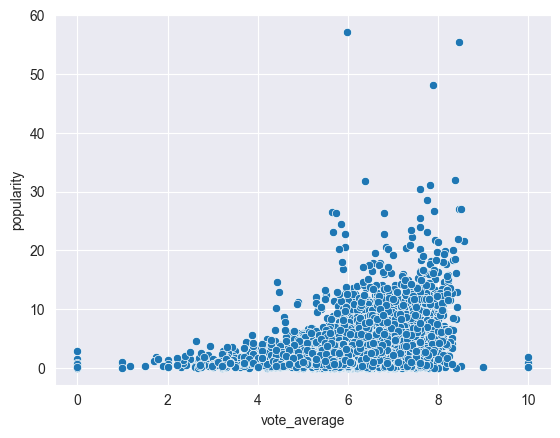

In [129]:
pop_and_vote = merged[['popularity','vote_average']]
sns.scatterplot(data = merged, x="vote_average",y = 'popularity')

In [130]:
countries = merged[['origin_countries','world_million_usd']]
countries['origin_countries'] = countries['origin_countries'].str.split(',')
country_revenue = countries.explode('origin_countries')
country_revenue['origin_countries'] = country_revenue['origin_countries'].str.strip()
country_revenue['country_group'] = country_revenue['origin_countries'].apply(
    lambda x: 'USA' if x == 'United States of America' else ('UK' if x == 'United Kingdom' else 'Inne')
)

grouped_revenue = country_revenue.groupby('country_group')['world_million_usd'].sum().reset_index()

# Zsumuj przychody dla każdego słowa kluczowego


In [133]:
grouped_revenue

,country_group,world_million_usd
0,Inne,102752.4
1,UK,67278.0
2,USA,432618.1


(np.float64(-1.099998020608606),
 np.float64(1.0999969778848018),
 np.float64(-1.0999994720577075),
 np.float64(1.0999959126227354))

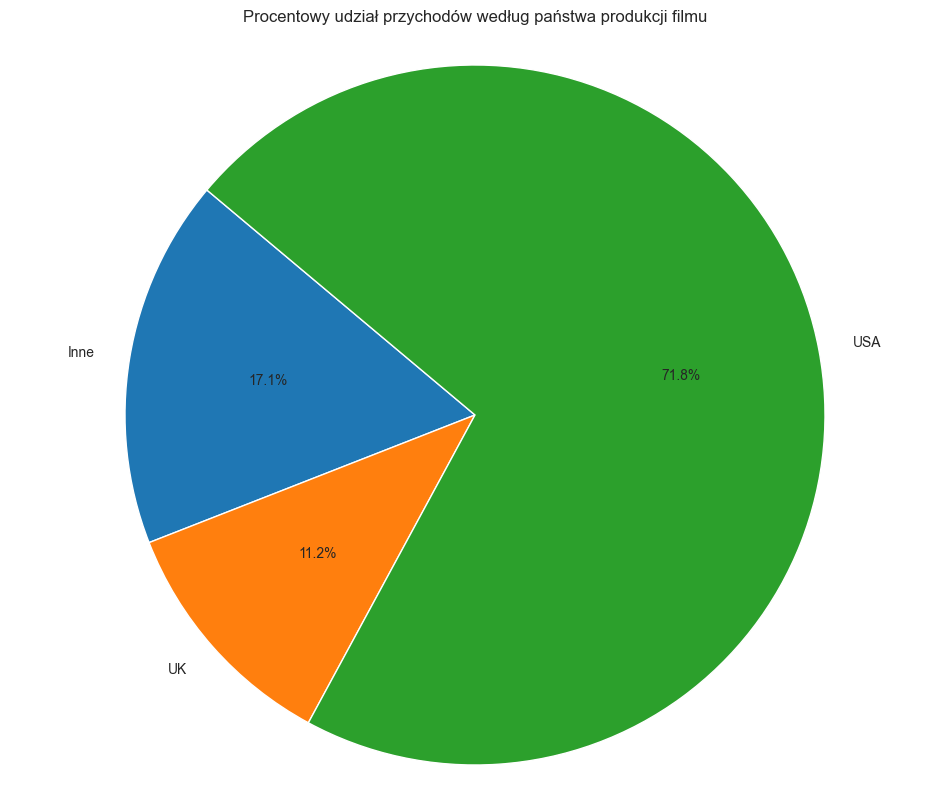

In [136]:
plt.figure(figsize=(12, 10))
plt.pie(grouped_revenue['world_million_usd'],
        labels=grouped_revenue['country_group'],
        autopct='%1.1f%%',
        startangle=140)
plt.title('Procentowy udział przychodów według państwa produkcji filmu')
plt.axis('equal')

In [153]:
eu_countries = merged[['origin_countries','world_million_usd']]
eu_countries['origin_countries'] = eu_countries['origin_countries'].str.split(',')
eu_revenue = countries.explode('origin_countries')
eu_revenue['origin_countries'] = eu_revenue['origin_countries'].str.strip()

eu = ['Germany','France','United Kingdom','Italy','Spain',
   'Bosnia and Herzegovina','Malta','Poland','Ukraine','Belarus',
      'Latvia','Estonia','Norway','Sweden','Finland','Greece','Turkey',
      'Ireland','Iceland','Netherlands','Austria','Belgium','Denmark',
      'Hungary','Romania','Moldova','Holy See','Yugoslavia','Macedonia'
      ,'Switzerland','Luxembourg','Liechtenstein','Russia','Croatia',
      'Cyprus','Czech Republic','Slovakia','Serbia','Lithuania',
      'Bulgaria']
eu_revenue['country_group'] = eu_revenue['origin_countries'].apply(
    lambda x: x if x in eu else 'Inne'
)
eu_revenue_g = eu_revenue[eu_revenue['country_group'] != 'Inne']

eu_grouped_revenue = eu_revenue_g.groupby('country_group')['world_million_usd'].sum().reset_index()
eu_grouped_revenue

,country_group,world_million_usd
0,Austria,65.0
1,Belgium,885.9
2,Bosnia and Herzegovina,32.6
3,Bulgaria,1026.8
4,Croatia,63.4
5,Cyprus,0.1
6,Czech Republic,1248.0
7,Denmark,311.8
8,Estonia,0.3
9,Finland,217.3


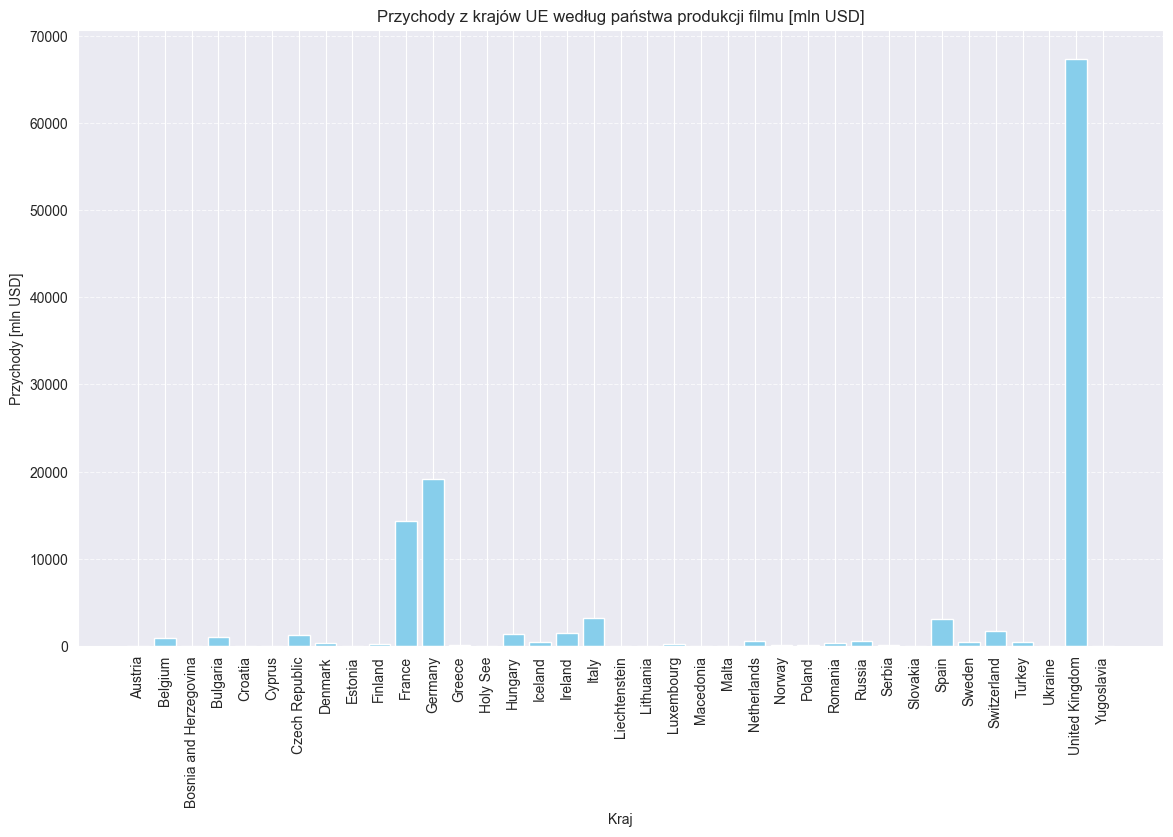

In [158]:
plt.figure(figsize=(14, 8))
plt.bar(
    eu_grouped_revenue['country_group'],
    eu_grouped_revenue['world_million_usd'],
    color='skyblue'
)
plt.xticks(rotation=90)
plt.title('Przychody z krajów UE według państwa produkcji filmu [mln USD]')
plt.xlabel('Kraj')

plt.ylabel('Przychody [mln USD]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()